# Vergleich von Aktien
## 1. Datenbeschaffung
### 1.1 Aktien und Zeitraum auswählen

In [1]:
import yfinance
import plotly.express as px
import pandas as pd

In [2]:
tickers = {
    "AAPL": "Apple (USA)",
    "NVDA": "NVIDIA (USA)",
    "ASML": "ASML (Niederlande)",
    "SAP": "SAP (Deutschland)",
    "TM": "Toyota (Japan)",
    "SONY": "Sony (Japan)",
}

start_date = "2021-08-01"
end_date = "2026-07-31"

Wir betrachten sechs Aktien aus vier Ländern (USA, Niederlande, Deutschland, Japan) über einen Zeitraum von fünf Jahren (01.08.2021-31.07.2026). Die Auswahl deckt unterschiedliche Branchen ab (Technologie, Halbleiter, Software, Automobil), um im späteren Vergleich sowohl ähnliche als auch unterschiedliche Wertentwicklungen zeigen zu können.

Ein besonderer Fokus liegt dabei aus ASML und NVIDIA. Beide Unternehmen sind eng mit dem Halbleiterzyklus verbunden, da ASML die Maschinen liefert, mit denen unter anderem NVIDIA-Chips hergestellt werden. Daraus ergibt sich die Hypothese, dass die Kursentwicklungen dieser beiden Aktien stärker miteinander korrelieren als mit den übrigen, branchenfremden Aktien im Vergleich.

### 1.2 Kursdaten herunterladen

In [3]:
data = yfinance.download(list(tickers.keys()), start=start_date, end=end_date, auto_adjust=True)
data.head()

[*********************100%***********************]  6 of 6 completed


Price            Close                                                \
Ticker            AAPL        ASML       NVDA         SAP       SONY   
Date                                                                   
2021-08-02  141.723694  734.308533  19.681921  131.754990  20.368086   
2021-08-03  143.515671  743.734924  19.746698  133.795837  20.227615   
2021-08-04  143.116333  758.952454  20.204115  134.577255  19.950577   
2021-08-05  143.223511  758.255920  20.565861  136.921478  20.063736   
2021-08-06  142.540756  747.312683  20.295799  134.558853  20.020815   

Price                         High                                     ...  \
Ticker              TM        AAPL        ASML       NVDA         SAP  ...   
Date                                                                   ...   
2021-08-02  162.836502  143.116381  740.214297  19.892194  132.940889  ...   
2021-08-03  166.480377  144.177924  744.612663  20.152295  133.814227  ...   
2021-08-04  163.105118  143.934415  761.900590  20.247964  135.184001  ...   
2021-08-05  163.713898  143.983161  768.645877  20.661530  137.252429  ...   
2021-08-06  161.797974  143.486868  751.043115  20.499097  135.634440  ...   

Price            Open                                       Volume          \
Ticker           NVDA         SAP       SONY          TM      AAPL    ASML   
Date                                                                         
2021-08-02  19.632094  131.506773  20.442223  162.943933  62880000  499900   
2021-08-03  19.671956  132.848953  20.405152  164.304813  64786600  533700   
2021-08-04  19.921093  134.108414  20.005204  163.570676  56368300  629700   
2021-08-05  20.429334  136.544559  20.284195  163.409500  46397700  723700   
2021-08-06  20.453256  135.101255  20.188597  162.173996  54126800  556900   

Price                                            
Ticker           NVDA      SAP     SONY      TM  
Date                                             
2021-08-02  217444000   382800  2037000  167500  
2021-08-03  301811000   742400  3666000  246900  
2021-08-04  231309000  1003100  3098500  194600  
2021-08-05  211435000   574200  2101500  128800  
2021-08-06  178497000   490300  2066000  183400  

[5 rows x 30 columns]

Die Kursdaten werden über die Python-Bibliothek `yfinance` abgerufen, die auf öffentlich verfügbare Daten von Yahoo Finance zugreift. Der Parameter `auto_adjust=True` sorgt dafür, dass die Kurse um Aktiensplits und Dividenden bereinigt sind. Ohne diese Bereinigung würden z. B. Aktiensplits (wie bei NVIDIA 2024) als künstliche Kurseinbrüche erscheinen.

### 1.3 Sanity-Check

In [4]:
print("Zeitraum von", data.index.min().date(), "bis", data.index.max().date())
print("Anzahl der Handelstage:", len(data))
print("Fehlende Werte je Aktie:")
print(data.isna().sum())

Zeitraum von 2021-08-02 bis 2026-07-30
Anzahl der Handelstage: 1254
Fehlende Werte je Aktie:
Price   Ticker
Close   AAPL      0
        ASML      0
        NVDA      0
        SAP       0
        SONY      0
        TM        0
High    AAPL      0
        ASML      0
        NVDA      0
        SAP       0
        SONY      0
        TM        0
Low     AAPL      0
        ASML      0
        NVDA      0
        SAP       0
        SONY      0
        TM        0
Open    AAPL      0
        ASML      0
        NVDA      0
        SAP       0
        SONY      0
        TM        0
Volume  AAPL      0
        ASML      0
        NVDA      0
        SAP       0
        SONY      0
        TM        0
dtype: int64


Vor der Weiterverarbeitung wird geprüft, ob die Daten vollständig sind und der erwartete Zeitraum abgedeckt ist.

## 2. Datenaufbereitung
### 2.1 Schlusskurse extrahieren und umbenennen

In [5]:
close = data["Close"].rename(columns = tickers).rename_axis(columns="Unternehmen")
close.head()

Unternehmen,Apple (USA),ASML (Niederlande),NVIDIA (USA),SAP (Deutschland),Sony (Japan),Toyota (Japan)
Date,,,,,,
2021-08-02,141.723694,734.308533,19.681921,131.754990,20.368086,162.836502
2021-08-03,143.515671,743.734924,19.746698,133.795837,20.227615,166.480377
2021-08-04,143.116333,758.952454,20.204115,134.577255,19.950577,163.105118
2021-08-05,143.223511,758.255920,20.565861,136.921478,20.063736,163.713898
2021-08-06,142.540756,747.312683,20.295799,134.558853,20.020815,161.797974


Aus den vollständigen Kursdaten wird nur der Schlusskurs weiterverwendet, da dieser für die Rendite- und Risikoberechnung die relevante Größe ist. Die Spalten werden umbenannt, um das Notebook lesbarer zu machen.

### 2.2 Tägliche Rendite

In [6]:
returns = close.pct_change().dropna()
returns.head()

Unternehmen,Apple (USA),ASML (Niederlande),NVIDIA (USA),SAP (Deutschland),Sony (Japan),Toyota (Japan)
Date,,,,,,
2021-08-03,0.012644,0.012837,0.003291,0.015490,-0.006897,0.022378
2021-08-04,-0.002783,0.020461,0.023164,0.005840,-0.013696,-0.020274
2021-08-05,0.000749,-0.000918,0.017905,0.017419,0.005672,0.003732
2021-08-06,-0.004767,-0.014432,-0.013132,-0.017255,-0.002139,-0.011703
2021-08-09,-0.000342,0.006894,-0.003486,0.001298,0.000097,-0.000830


Die tägliche Rendite zeigt, um wie viel Prozent sich der Kurs von einem Tag auf den nächsten verändert hat.

Beispiel:  
Der Apple-Kurs lag am 02.08.2021 bei 141,85 USD und am 03.08.2021 bei 143,64 USD.
Das entspricht einem Anstieg von 1,79 USD, also rund +1,26 %.

## 3. Kennzahlen
### 3.1 Kumulierte Rendite

In [7]:
cumulative_return = (1 + returns).cumprod() - 1
cumulative_return.tail()

Unternehmen,Apple (USA),ASML (Niederlande),NVIDIA (USA),SAP (Deutschland),Sony (Japan),Toyota (Japan)
Date,,,,,,
2026-07-24,1.347759,1.389759,9.509137,0.214375,0.030043,0.089559
2026-07-27,1.375183,1.251264,8.984289,0.297939,0.094359,0.118607
2026-07-28,1.397531,1.155701,9.009693,0.359873,0.114980,0.144092
2026-07-29,1.384207,1.111769,8.654037,0.411635,0.142474,0.184255
2026-07-30,1.350649,1.248973,8.909601,0.372851,0.117925,0.175719


Die kumulierte Rendite zeigt, was aus einem angelegten Betrag über die Zeit geworden wäre, wenn man alle täglichen Veränderungen mitnimmt.

Beispiel:  
Bei NVIDIA steht am Ende des Zeitraums eine kumulierte Rendite von rund 8,91 (also +891 %).
Das heißt: Aus 100 € investiert am 01.08.2021 wären bis zum 30.07.2026 etwa 991 € geworden.

Wichtig dabei:  
Die täglichen Veränderungen bauen aufeinander auf.
Ein Gewinn von einem Tag wirkt sich am nächsten Tag mit aus, weil er schon Teil des neuen Kurses ist.

### 3.2 Jährliche Volatilität

In [8]:
volatility = returns.std() * (252 ** 0.5)
volatility

Unternehmen
Apple (USA)           0.278409
ASML (Niederlande)    0.432816
NVIDIA (USA)          0.518987
SAP (Deutschland)     0.297359
Sony (Japan)          0.292453
Toyota (Japan)        0.271929
dtype: float64

Die Volatilität zeigt, wie stark der Kurs einer Aktie schwankt.

Beispiel:  
Toyota hat mit rund 27 % die niedrigste Volatilität, der Kurs bewegt sich vergleichsweise gleichmäßig.
NVIDIA hat mit rund 52 % fast doppelt so hohe Schwankungen, der Kurs macht größere Sprünge nach oben und unten.

Hohe Volatilität bedeutet höheres Risiko, aber oft auch die Chance auf höhere Gewinne.
Bei NVIDIA sieht man beides: die höchste Schwankung und die höchste Rendite.

### 3.3 Sharpe Ratio

In [9]:
annualized_return = returns.mean() * 252
sharpe_ratio = annualized_return / volatility
sharpe_ratio

Unternehmen
Apple (USA)           0.756079
ASML (Niederlande)    0.593050
NVIDIA (USA)          1.146121
SAP (Deutschland)     0.363118
Sony (Japan)          0.222402
Toyota (Japan)        0.254728
dtype: float64

Die Sharpe Ratio zeigt, wie viel Rendite eine Aktie pro Einheit eingegangenem Risiko liefert (hier vereinfacht mit risikofreiem Zins = 0).

Beispiel:  
NVIDIA hat mit 1,15 die höchste Sharpe Ratio, trotz der hohen Volatilität wird das Risiko durch die außergewöhnlich hohe Rendite mehr als ausgeglichen. Apple liegt mit 0,76 an zweiter Stelle, obwohl die Volatilität niedriger ist als bei ASML (0,59) oder SAP (0,36). Apple liefert also nach NVIDIA die "effizienteste" Rendite pro Risiko.

Sony (0,22) und Toyota (0,25) haben die niedrigsten Sharpe Ratios. Eher geringe Renditen bei einer Volatilität, die nicht wesentlich niedriger ist als bei den anderen Aktien. Das eingegangene Risiko lohnt sich hier vergleichsweise am wenigsten.

### 3.4 Maximaler Drawdown

In [10]:
running_max = close.cummax()
drawdown = (close - running_max) / running_max
max_drawdown = drawdown.min()
max_drawdown

Unternehmen
Apple (USA)          -0.333605
ASML (Niederlande)   -0.568618
NVIDIA (USA)         -0.663351
SAP (Deutschland)    -0.522570
Sony (Japan)         -0.505593
Toyota (Japan)       -0.368022
dtype: float64

Der maximale Drawdown zeigt den größten Wertverlust, den eine Aktie vom bisherigen Höchststand bis zu ihrem nachfolgenden Tiefpunkt erlitten hat.

Beispiel:  
NVIDIA hatte mit -66 % den stärksten Einbruch. Wer am absoluten Höchstpunkt gekauft hätte, hätte zwischenzeitlich zwei Drittel des Werts verloren, bevor sich die Aktie erholte.
Apple war mit -33 % am stabilsten.

Auffällig:  
SAP (-52 %) und Sony (-51 %) hatten trotz vergleichsweise niedriger Volatilität und niedriger Sharpe Ratio fast genauso tiefe Einbrüche wie ASML (-57 %).

Das zeigt:  
Volatilität misst eher die täglichen Schwankungen, während der maximale Drawdown einen anhaltenden Abwärtstrend über einen längeren Zeitraum erfasst.
Beide Kennzahlen zusammen ergeben ein vollständigeres Risikobild als jede für sich allein.

In [11]:
(cumulative_return["NVIDIA (USA)"] - cumulative_return["NVIDIA (USA)"].cummax()).idxmin()

Timestamp('2025-04-04 00:00:00')

Der tiefste Punkt des Drawdowns liegt am 4. April 2025 und fällt damit in die unmittelbare Folge von US-Präsident Trumps "Liberation Day"-Zöllen.

Am 2. April 2025 kündigte die US-Regierung breite neue Importzölle gegenüber nahezu allen Handelspartnern an, was an den folgenden Handelstagen zu einem der stärksten globalen Kurseinbrüche seit der Corona-Pandemie führte. Technologie- und Halbleiterwerte wie NVIDIA waren davon besonders stark betroffen, da ihre Lieferketten global verflochten sind und die neuen Zölle direkte Auswirkungen auf Produktionskosten und Absatzmärkte befürchten ließen.

### 3.5 Korrelationsmatrix

In [12]:
correlation_matrix = returns.corr()
correlation_matrix

Unternehmen,Apple (USA),ASML (Niederlande),NVIDIA (USA),SAP (Deutschland),Sony (Japan),Toyota (Japan)
Unternehmen,,,,,,
Apple (USA),1.000000,0.482138,0.485503,0.412070,0.435766,0.397315
ASML (Niederlande),0.482138,1.000000,0.659557,0.396505,0.393712,0.389986
NVIDIA (USA),0.485503,0.659557,1.000000,0.384321,0.392709,0.338143
SAP (Deutschland),0.412070,0.396505,0.384321,1.000000,0.402798,0.307407
Sony (Japan),0.435766,0.393712,0.392709,0.402798,1.000000,0.465840
Toyota (Japan),0.397315,0.389986,0.338143,0.307407,0.465840,1.000000


Die Korrelationsmatrix zeigt, wie stark sich die Renditen der sechs Aktien im Gleichlauf bewegen.

Auffällig:  
ASML und NVIDIA haben mit 0,66 die höchste Korrelation im gesamten Vergleich, deutlich höher als jedes andere Aktienpaar. Das bestätigt die in Abschnitt 1.1 aufgestellte Hypothese: Beide Unternehmen sind eng mit dem Halbleiterzyklus verbunden (ASML liefert die Maschinen, mit denen u. a. NVIDIA-Chips hergestellt werden), wodurch sich ihre Kursbewegungen stärker ähneln als bei branchenfremden Paaren.

Am schwächsten korreliert sind NVIDIA und Toyota (0,34) sowie SAP und Toyota (0,31). Zwei Unternehmen aus völlig unterschiedlichen Branchen und Weltregionen bewegen sich am unabhängigsten voneinander.

Insgesamt sind alle Korrelationen positiv, kein Aktienpaar bewegt sich gegenläufig. Das ist typisch für global gehandelte Aktien, die alle von übergeordneten Markteinflüssen (z. B. Zinsentscheidungen, Konjunktur) mitbestimmt werden. Der Unterschied liegt im Ausmaß, branchennahe Aktien bewegen sich deutlich synchroner als branchenfremde.

Aus den Korrelationen lassen sich auch Rückschlüsse auf Diversifikationseffekte ziehen. Je niedriger die Korrelation zwischen zwei Aktien, desto stärker gleichen sich ihre Kursbewegungen in einem gemeinsamen Portfolio aus, wodurch sich das Gesamtrisiko reduzieren lässt. Eine Kombination aus NVIDIA und Toyota oder aus SAP und Toyota würde demnach eine stärkere Risikostreuung bieten als eine Kombination aus ASML und NVIDIA, deren Kurse sich mit 0,66 am stärksten gleichläufig entwickeln und sich im Portfolio kaum gegenseitig ausgleichen.

## 4. Visualisierung
### 4.1 Kumulierte Rendite im Vergleich

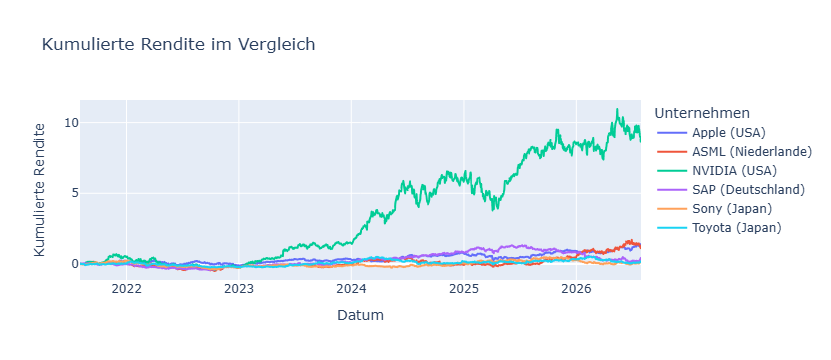

In [13]:
fig = px.line(cumulative_return, title="Kumulierte Rendite im Vergleich")
fig.update_layout(xaxis_title="Datum", yaxis_title="Kumulierte Rendite")
fig.show()

Der Chart bestätigt visuell, was die Kennzahlen aus Kapitel 3 bereits gezeigt haben. NVIDIAs Kurve dominiert den Verlauf deutlich, mit sichtbaren zwischenzeitlichen Einbrüchen (passend zum berechneten maximalen Drawdown von -66 %). Der steile Anstieg ab etwa 2023 fällt zeitlich mit dem KI-Boom zusammen. Die übrigen fünf Aktien lassen sich bei dieser Skalierung kaum noch voneinander unterscheiden, da NVIDIAs Wertentwicklung die Skala dominiert.

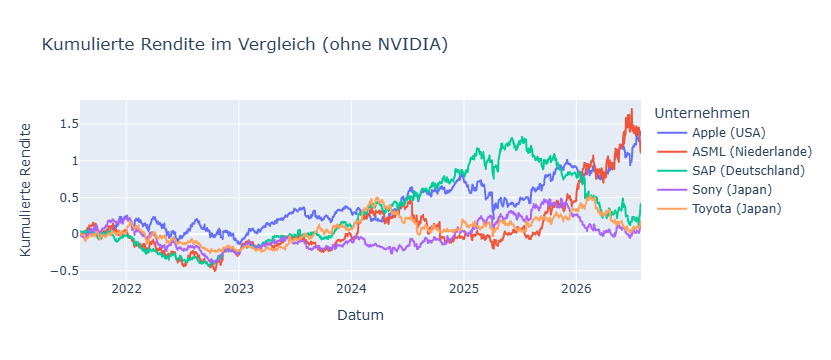

In [14]:
fig2 = px.line(
    cumulative_return.drop(columns="NVIDIA (USA)"),
    title="Kumulierte Rendite im Vergleich (ohne NVIDIA)"
)
fig2.update_layout(xaxis_title="Datum", yaxis_title="Kumulierte Rendite")
fig2.show()

Ohne NVIDIA wird sichtbar, dass auch Apple und ASML mit rund +135 % bzw. +125 % deutlich stärker gewachsen sind als SAP (+37 %), Sony (+12 %) und Toyota (+18 %). Auffällig ist auch, dass SAP zwischen 2023 und 2025 zeitweise vor Apple und ASML lag, gegen Ende des Betrachtungszeitraums aber von beiden überholt wurde.

### 4.2 Übersicht der Kennzahlen

In [15]:
summary = pd.DataFrame({
    "Kumulierte Rendite": cumulative_return.iloc[-1],
    "Volatilität": volatility,
    "Sharpe Ratio": sharpe_ratio,
    "Max. Drawdown": max_drawdown
}).sort_values("Sharpe Ratio", ascending=False)
summary

,Kumulierte Rendite,Volatilität,Sharpe Ratio,Max. Drawdown
Unternehmen,,,,
NVIDIA (USA),8.909601,0.518987,1.146121,-0.663351
Apple (USA),1.350649,0.278409,0.756079,-0.333605
ASML (Niederlande),1.248973,0.432816,0.593050,-0.568618
SAP (Deutschland),0.372851,0.297359,0.363118,-0.522570
Toyota (Japan),0.175719,0.271929,0.254728,-0.368022
Sony (Japan),0.117925,0.292453,0.222402,-0.505593


Als Ranking für die relative Performance wird die Sharpe Ratio herangezogen, da sie Rendite und Risiko bereits in einer Kennzahl zusammenführt (siehe 3.3) und damit aussagekräftiger ist als eine reine Sortierung nach Rendite. NVIDIA führt das Ranking mit deutlichem Abstand an, gefolgt von Apple und ASML. SAP, Toyota und Sony bilden das untere Ende, mit vergleichsweise geringer Rendite pro eingegangenem Risiko.

### 4.3 Vergleich der Kennzahlen

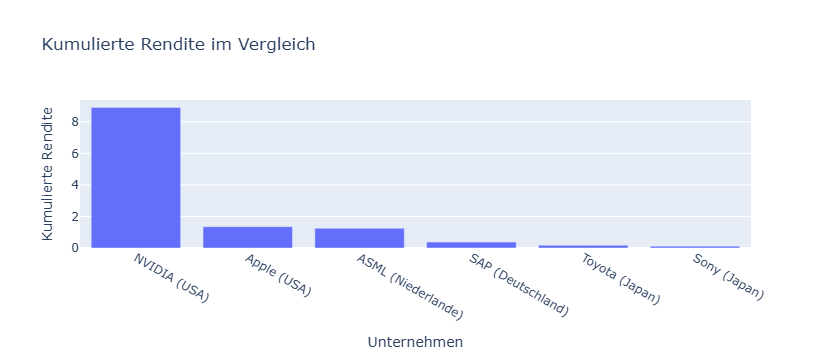

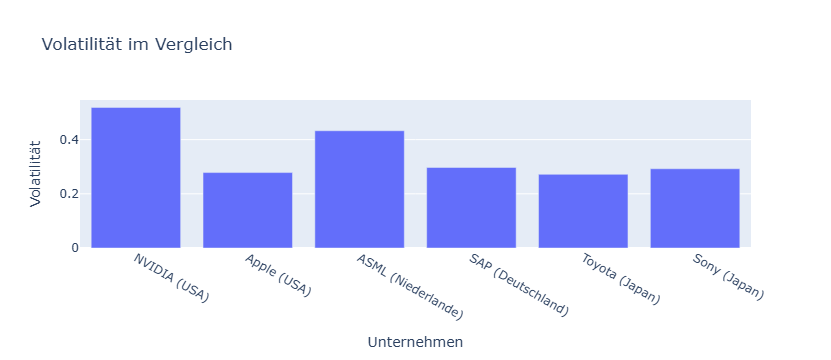

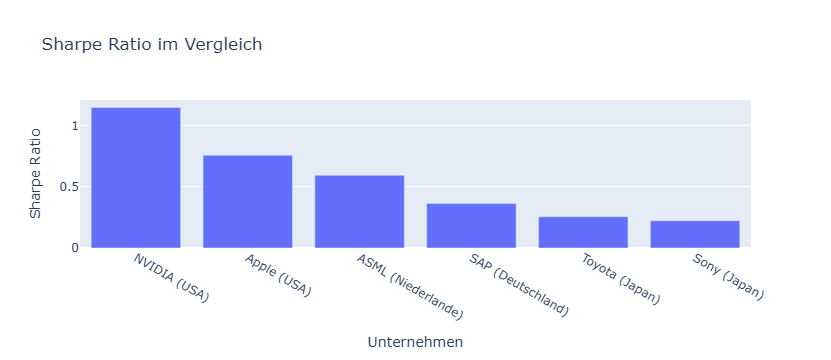

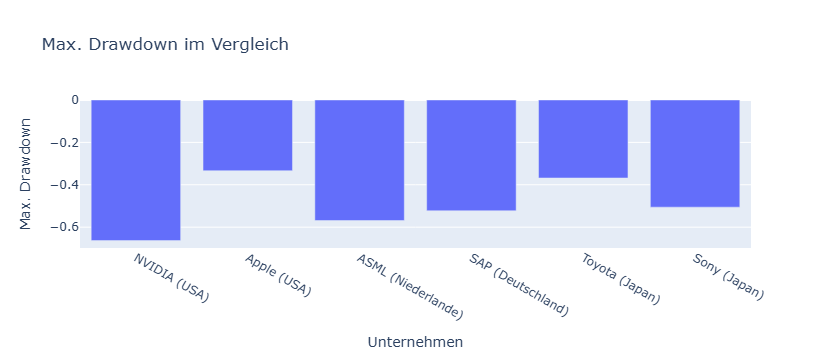

In [16]:
for column in summary.columns:
    fig = px.bar(summary, y=column, title=f"{column} im Vergleich")
    fig.show()

Die Balkendiagramme fassen die Kennzahlen aus Kapitel 3 nochmal im direkten Vergleich zusammen. NVIDIA führt bei Rendite, Volatilität und Sharpe Ratio klar vor allen anderen Aktien, hat dafür aber auch den tiefsten Drawdown. Apple sticht bei der Sharpe Ratio als zweitbeste Aktie hervor, obwohl die Volatilität nur im Mittelfeld liegt, ein Hinweis auf eine besonders effiziente Rendite pro Risiko. Sony und Toyota liegen bei allen vier Kennzahlen eher im unteren Bereich, sprich solide, aber wenig dynamisch.

### 4.4 Korrelations-Heatmap

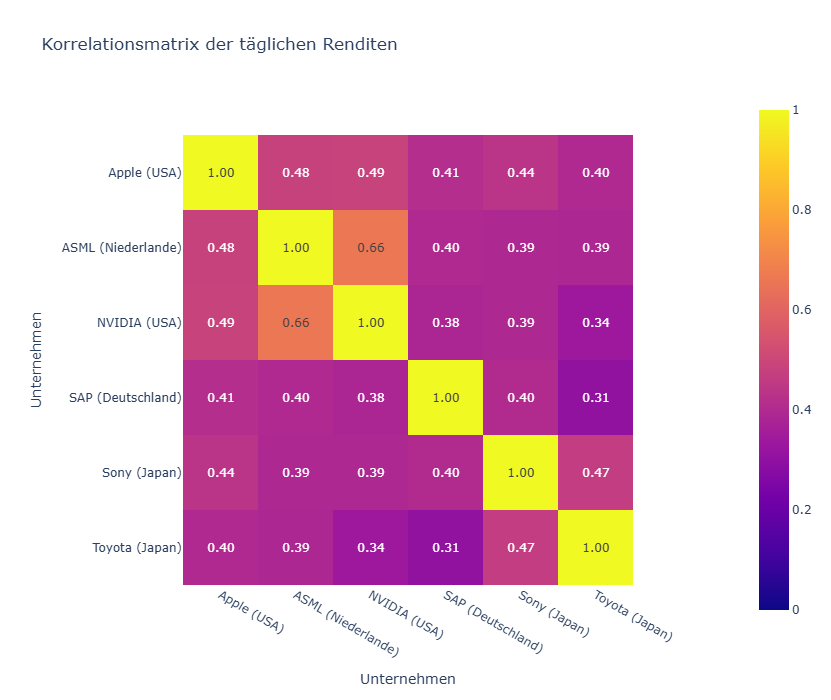

In [17]:
fig = px.imshow(
    correlation_matrix,
    text_auto=".2f",
    title="Korrelationsmatrix der täglichen Renditen",
    zmin=0,
    zmax=1,
    width=700,
    height=700
)
fig.show()

Die Heatmap macht den auffälligen Zusammenhang zwischen ASML und NVIDIA auf einen Blick sichtbar. Ihr Feld ist deutlich heller eingefärbt als alle anderen Nicht-Diagonal-Felder, ein direkter visueller Beleg für die in 3.5 besprochene Hypothese.

### 4.5 Risiko-Rendite-Profil

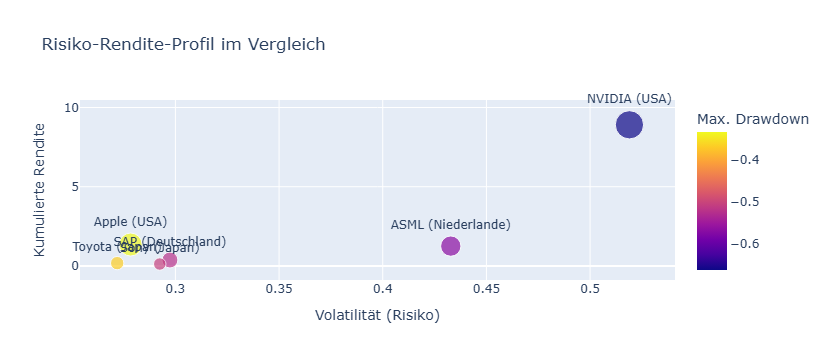

In [18]:
fig = px.scatter(
    summary,
    x="Volatilität",
    y="Kumulierte Rendite",
    text=summary.index,
    size="Sharpe Ratio",
    color="Max. Drawdown",
    title="Risiko-Rendite-Profil im Vergleich"
)
fig.update_traces(textposition="top center", cliponaxis=False)
fig.update_layout(xaxis_title="Volatilität (Risiko)", yaxis_title="Kumulierte Rendite")
fig.show()

Der Scatterplot führt die vier Kennzahlen aus Kapitel 3 in einer Ansicht zusammen und macht den Zusammenhang zwischen Risiko und Rendite auf einen Blick sichtbar.

Auffällig:  
NVIDIA liegt weit oben rechts, die mit Abstand höchste Rendite bei gleichzeitig höchster Volatilität, zusätzlich sichtbar an der Punktgröße (höchste Sharpe Ratio) und der dunkelsten Einfärbung (tiefster Drawdown). Das bestätigt noch einmal visuell den klassischen Zusammenhang, dass höhere Rendite mit höherem Risiko einhergehen. Toyota und Sony liegen dagegen unten links, niedrige Volatilität, aber auch niedrige Rendite und kleine Punkte (niedrige Sharpe Ratio). Apple sticht als Punkt mit vergleichsweise kleiner Größe im Verhältnis zu seiner Position hervor. Eine moderate Volatilität, aber überdurchschnittliche Rendite, was die zuvor berechnete hohe Sharpe Ratio bestätigt.

## 5. Fazit und Reflexion

In diesem Projekt wurden sechs internationale Aktien aus vier Ländern und unterschiedlichen Branchen über einen Zeitraum von fünf Jahren analysiert und miteinander verglichen. Dabei wurden grundlegende Rendite- und Risikokennzahlen berechnet sowie die Zusammenhänge zwischen den Aktien untersucht.

**Bezug zur Ausgangs-Hypothese:** Die eingangs aufgestellte Vermutung, dass halbleiternahe Aktien (ASML, NVIDIA) stärker korrelieren als branchenfremde Aktien, hat sich bestätigt. Mit 0,66 weisen ASML und NVIDIA die höchste Korrelation im gesamten Vergleich auf, deutlich vor allen anderen Aktienpaaren.

**Wichtigste Erkenntnisse:** NVIDIA zeigt die mit Abstand höchste Rendite, Volatilität und Sharpe Ratio, aber auch den tiefsten Drawdown, ein klares Beispiel für den Zusammenhang von Chance und Risiko. Apple erzielt die zweitbeste Sharpe Ratio bei moderater Volatilität und liefert damit die "effizienteste" Rendite nach NVIDIA. Sony und Toyota entwickeln sich über alle Kennzahlen hinweg am stabilsten, aber auch am wenigsten dynamisch.

**Kritische Reflexion:** Bei der Analyse wurden bewusst einige Vereinfachungen getroffen. Der risikofreie Zins wurde für die Sharpe Ratio auf 0 gesetzt, da es primär um den relativen Vergleich zwischen den sechs Aktien ging. Zudem wurde ein fester Betrachtungszeitraum von fünf Jahren gewählt, der von der außergewöhnlich starken KI-getriebenen Entwicklung geprägt ist. Ein anderer Zeitraum könnte zu abweichenden Ergebnissen führen. Auch wurde nicht statistisch geprüft, ob die beobachteten Unterschiede bei den Korrelationen zufällig zustande gekommen sein könnten oder tatsächlich bedeutsam sind. Für eine tiefere Analyse wäre es denkbar, einen längeren oder anderen
Betrachtungszeitraum zu wählen oder weitere Aktien bzw. Branchen in den Vergleich einzubeziehen.